# News Category Classification using TensorFlow.
Identifies SPORTS, POLITICS, BUSINESS, TECHNOLOGY

In [15]:
import pandas as pd
import numpy as np
import tensorflow as tf

In [14]:
df = pd.read_json("/News_Category_Dataset_v3.json", lines=True)

df.head()

,link,headline,category,short_description,authors,date
0,https://www.huffpost.com/entry/covid-boosters-...,Over 4 Million Americans Roll Up Sleeves For O...,U.S. NEWS,Health experts said it is too early to predict...,"Carla K. Johnson, AP",2022-09-23
1,https://www.huffpost.com/entry/american-airlin...,"American Airlines Flyer Charged, Banned For Li...",U.S. NEWS,He was subdued by passengers and crew when he ...,Mary Papenfuss,2022-09-23
2,https://www.huffpost.com/entry/funniest-tweets...,23 Of The Funniest Tweets About Cats And Dogs ...,COMEDY,"""Until you have a dog you don't understand wha...",Elyse Wanshel,2022-09-23
3,https://www.huffpost.com/entry/funniest-parent...,The Funniest Tweets From Parents This Week (Se...,PARENTING,"""Accidentally put grown-up toothpaste on my to...",Caroline Bologna,2022-09-23
4,https://www.huffpost.com/entry/amy-cooper-lose...,Woman Who Called Cops On Black Bird-Watcher Lo...,U.S. NEWS,Amy Cooper accused investment firm Franklin Te...,Nina Golgowski,2022-09-22


In [16]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 209527 entries, 0 to 209526
Data columns (total 6 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   link               209527 non-null  object        
 1   headline           209527 non-null  object        
 2   category           209527 non-null  object        
 3   short_description  209527 non-null  object        
 4   authors            209527 non-null  object        
 5   date               209527 non-null  datetime64[ns]
dtypes: datetime64[ns](1), object(5)
memory usage: 9.6+ MB
None


In [17]:
# select categories
selected_categories = ['SPORTS', 'POLITICS', 'BUSINESS', 'TECH']

# filter dataset
df = df[df['category'].isin(selected_categories)]

# show category counts
print(df['category'].value_counts())

category
POLITICS    35602
BUSINESS     5992
SPORTS       5077
TECH         2104
Name: count, dtype: int64


In [18]:
# Keeps only required columns
df = df[['headline', 'category']]

df.head()

,headline,category
13,Twitch Bans Gambling Sites After Streamer Scam...,TECH
17,"Maury Wills, Base-Stealing Shortstop For Dodge...",SPORTS
21,Biden Says U.S. Forces Would Defend Taiwan If ...,POLITICS
24,‘Beautiful And Sad At The Same Time’: Ukrainia...,POLITICS
26,"Las Vegas Aces Win First WNBA Title, Chelsea G...",SPORTS


In [19]:
category_mapping = {
    'SPORTS': 0,
    'POLITICS': 1,
    'BUSINESS': 2,
    'TECH': 3
}

df['label'] = df['category'].map(category_mapping)

df.head()

,headline,category,label
13,Twitch Bans Gambling Sites After Streamer Scam...,TECH,3
17,"Maury Wills, Base-Stealing Shortstop For Dodge...",SPORTS,0
21,Biden Says U.S. Forces Would Defend Taiwan If ...,POLITICS,1
24,‘Beautiful And Sad At The Same Time’: Ukrainia...,POLITICS,1
26,"Las Vegas Aces Win First WNBA Title, Chelsea G...",SPORTS,0


In [20]:
texts = df['headline'].values

labels = df['label'].values

print(texts[:5])
print(labels[:5])

['Twitch Bans Gambling Sites After Streamer Scams Folks Out Of $200,000'
 'Maury Wills, Base-Stealing Shortstop For Dodgers, Dies At 89'
 'Biden Says U.S. Forces Would Defend Taiwan If China Invaded'
 '‘Beautiful And Sad At The Same Time’: Ukrainian Cultural Festival Takes On A Deeper Meaning This Year'
 'Las Vegas Aces Win First WNBA Title, Chelsea Gray Named MVP']
[3 0 1 1 0]


In [21]:
from sklearn.model_selection import train_test_split

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    texts,
    labels,
    test_size=0.2,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 39020
Testing samples: 9755


In [22]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Vocabulary size
vocab_size = 10000

# Maximum length of headline
max_length = 20

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

# Convert text to sequences
X_train_sequences = tokenizer.texts_to_sequences(X_train)
X_test_sequences = tokenizer.texts_to_sequences(X_test)

X_train_padded = pad_sequences(X_train_sequences, maxlen=max_length, padding='post')
X_test_padded = pad_sequences(X_test_sequences, maxlen=max_length, padding='post')

print(X_train_padded.shape)
print(X_test_padded.shape)

(39020, 20)
(9755, 20)


In [23]:
model = tf.keras.Sequential([
    tf.keras.layers.Embedding(vocab_size, 64, input_length=max_length),
    tf.keras.layers.GlobalAveragePooling1D(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(4, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [24]:
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [25]:
history = model.fit(
    X_train_padded,
    y_train,
    epochs=5,
    validation_data=(X_test_padded, y_test)
)

Epoch 1/5
1220/1220 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.8006 - loss: 0.5708 - val_accuracy: 0.8627 - val_loss: 0.3637
Epoch 2/5
1220/1220 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.8985 - loss: 0.2833 - val_accuracy: 0.8801 - val_loss: 0.3430
Epoch 3/5
1220/1220 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.9281 - loss: 0.2068 - val_accuracy: 0.8746 - val_loss: 0.3379
Epoch 4/5
1220/1220 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.9433 - loss: 0.1645 - val_accuracy: 0.8929 - val_loss: 0.3230
Epoch 5/5
1220/1220 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.9537 - loss: 0.1347 - val_accuracy: 0.8858 - val_loss: 0.3662


In [26]:
# Evaluate model
loss, accuracy = model.evaluate(X_test_padded, y_test)

print("Test Accuracy:", accuracy)

305/305 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8858 - loss: 0.3662
Test Accuracy: 0.885802149772644


In [27]:
# Reverse mapping
reverse_mapping = {
    0: 'SPORTS',
    1: 'POLITICS',
    2: 'BUSINESS',
    3: 'TECH'
}

# Example headlines
sample_headlines = [
    "India wins cricket world cup final",
    "Government announces new economic policy",
    "Apple launches new AI powered iPhone",
    "Stock market reaches all time high"
]

sample_sequences = tokenizer.texts_to_sequences(sample_headlines)

sample_padded = pad_sequences(sample_sequences, maxlen=max_length, padding='post')

# Predict
predictions = model.predict(sample_padded)

# Show predictions
for i, headline in enumerate(sample_headlines):
    predicted_label = np.argmax(predictions[i])
    print(f"Headline: {headline}")
    print(f"Predicted Category: {reverse_mapping[predicted_label]}")
    print()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
Headline: India wins cricket world cup final
Predicted Category: SPORTS

Headline: Government announces new economic policy
Predicted Category: POLITICS

Headline: Apple launches new AI powered iPhone
Predicted Category: TECH

Headline: Stock market reaches all time high
Predicted Category: BUSINESS



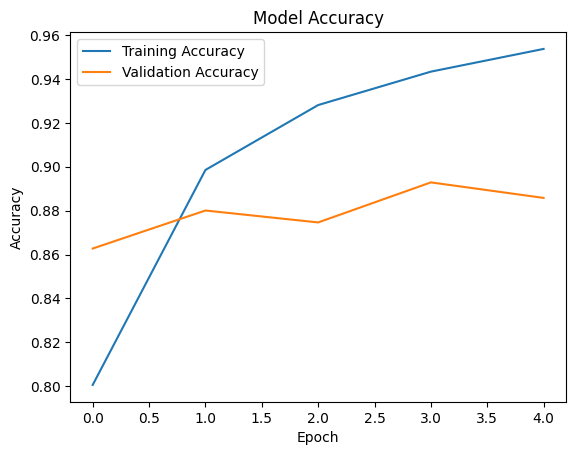

In [28]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

plt.legend(['Training Accuracy', 'Validation Accuracy'])

plt.show()

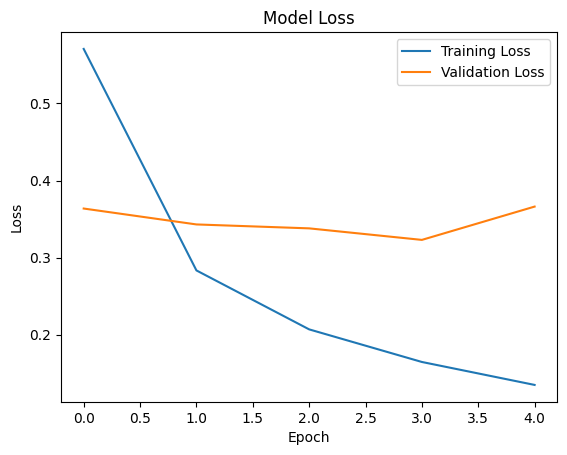

In [29]:
# Plot training & validation loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')

plt.legend(['Training Loss', 'Validation Loss'])

plt.show()

# Conclusion

This project successfully classified news headlines into multiple categories using TensorFlow and Natural Language Processing techniques.

The model was trained on news headline data and achieved good classification accuracy on the testing dataset.

The categories used in this project were:
- Sports
- Politics
- Business
- Technology

TensorFlow, Keras, Pandas, NumPy, and Matplotlib were used to build and evaluate the model.